# PE7 mouse multiplexed editing coverage

**Kexin Dong**

Createed: Apr 27, 2026;

Last updated: May 20, 2026

This notebook quantifies cancer-associated mutation combinations amenable to modeling by PE7 multiplexed prime editing.

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats
import seaborn as sns
import warnings
import os 
from pegg import prime
import bioh2m as h2m
import matplotlib.patheffects as PathEffects
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
import re
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42   
mpl.rcParams['ps.fonttype'] = 42 
mpl.rcParams['text.usetex'] = False
from scipy.stats import combine_pvalues

yellows = sns.color_palette('Oranges').as_hex()
blues   = sns.color_palette('Blues').as_hex()
greens  = sns.color_palette('Greens').as_hex()
reds    = sns.color_palette('Reds').as_hex()
purples = sns.color_palette('Purples').as_hex()

In [36]:
purple_muted = '#8E8AB8'   # parental / wild-type
green_muted  = '#7FA77F'   # variant family
blue_pair    = '#5A8DC8'   # single / category A
gold_pair    = '#E8B85F'   # combination / category B
red_ctrl     = '#C86A6A'   # negative controls
gray_bg      = '#C8C8C8'   # background scatter

# sequential blues (panel i)
blues_5 = sns.color_palette('Blues', 6)[1:]   # skip lightest
# sequential greens (panel j)
greens_5 = sns.color_palette('Greens', 6)[1:]

# diverging (panel e)
diverging = sns.diverging_palette(230, 20, s=60, l=70, as_cmap=True)

## Overview and Rationale

Aim: Show that PE7 multiplexed prime editing expands the spectrum of cancer driver mutation combinations that can be modeled in mice.


- Use AACR-GENIE as the patient cohort (pan-cancer, reasonably sized — PEGG guide generation is slow so we avoid going huge).
    - Compute VAF per mutation as t_alt_count / (t_alt_count + t_ref_count); drop rows without VAF info.
    - Map top-VAF human mutations to mouse alleles via H2M Database v1.
    - Run PEGG on these mouse alleles to determine which can be modeled with PE.

## Data Sources
- AACR-GENIE
- MMRRC: https://www.mmrrc.org/
- PEGG pipeline: https://www.nature.com/articles/s41587-024-02172-9
- H2M: https://www.nature.com/articles/s41587-025-02925-0

In [37]:
# use v15 to stay consistent with H2M Database
df_mutation_aacr = pd.read_csv('/Users/kexindong/Documents/GitHub/Database/PublicDatabase/AACR-GENIE/v15.0/data_mutations_extended.txt',
                          header=0, sep='\t', comment="#", 
                          na_values=['Not Applicable', 'NA', 'NULL', '-', 'None', ''])
df_pts = pd.read_csv('/Users/kexindong/Documents/GitHub/Database/PublicDatabase/AACR-GENIE/v15.0/data_clinical_patient.txt', header=0, sep='\t', comment="#", na_values = ['Not Applicable', 'NA', 'NULL', '-', 'None', ''])
df_sample = pd.read_csv('/Users/kexindong/Documents/GitHub/Database/PublicDatabase/AACR-GENIE/v15.0/data_clinical_sample.txt', header=0, sep='\t', comment="#", na_values = ['Not Applicable', 'NA', 'NULL', '-', 'None', ''])

In [38]:
# TODO:
# calculate VAF and insert after 'Tumor_Seq_Allele2', and drop rows with missing VAF
df_mutation_aacr['VAF'] = df_mutation_aacr['t_alt_count'] / (df_mutation_aacr['t_alt_count'] + df_mutation_aacr['t_ref_count'])
insert_idx = df_mutation_aacr.columns.get_loc('Tumor_Seq_Allele2') + 1
df_mutation_aacr.insert(insert_idx, 'VAF', df_mutation_aacr.pop('VAF'))

n_before = len(df_mutation_aacr)
df_mutation_aacr = df_mutation_aacr[df_mutation_aacr['VAF'].notna()].reset_index(drop=True)
n_after = len(df_mutation_aacr)

print(f'Mutations: {n_before:,} -> {n_after:,} ({n_after/n_before*100:.1f}% kept)')
print(f'Unique patients with VAF info: {df_mutation_aacr["Tumor_Sample_Barcode"].nunique():,}')

Mutations: 1,840,311 -> 1,381,528 (75.1% kept)
Unique patients with VAF info: 131,529


In [39]:
# TODO:
# keep at most three mutations for each sample, and keep the one with highest VAF if there are multiple mutations for the same sample
df_mutation_aacr = df_mutation_aacr.sort_values(['Tumor_Sample_Barcode', 'VAF'], ascending=[True, False]).groupby('Tumor_Sample_Barcode').head(3).reset_index(drop=True)

In [40]:
df_mutation_aacr.columns

Index(['Hugo_Symbol', 'Entrez_Gene_Id', 'Center', 'NCBI_Build', 'Chromosome',
       'Start_Position', 'End_Position', 'Strand', 'Consequence',
       'Variant_Classification', 'Variant_Type', 'Reference_Allele',
       'Tumor_Seq_Allele1', 'Tumor_Seq_Allele2', 'VAF', 'dbSNP_RS',
       'dbSNP_Val_Status', 'Tumor_Sample_Barcode',
       'Matched_Norm_Sample_Barcode', 'Match_Norm_Seq_Allele1',
       'Match_Norm_Seq_Allele2', 'Tumor_Validation_Allele1',
       'Tumor_Validation_Allele2', 'Match_Norm_Validation_Allele1',
       'Match_Norm_Validation_Allele2', 'Verification_Status',
       'Validation_Status', 'Mutation_Status', 'Sequencing_Phase',
       'Sequence_Source', 'Validation_Method', 'Score', 'BAM_File',
       'Sequencer', 't_ref_count', 't_alt_count', 'n_ref_count', 'n_alt_count',
       'HGVSc', 'HGVSp', 'HGVSp_Short', 'Transcript_ID', 'RefSeq',
       'Protein_position', 'Codons', 'Exon_Number', 'gnomAD_AF',
       'gnomAD_AFR_AF', 'gnomAD_AMR_AF', 'gnomAD_ASJ_AF', 'gnomAD

In [41]:
df_mutation_aacr['Hugo_Symbol'].value_counts().head(20)

Hugo_Symbol
TP53      42901
KRAS      13673
PIK3CA     8124
APC        6745
EGFR       5344
PTEN       4870
TERT       4774
BRAF       4311
ARID1A     3508
KMT2D      3381
TET2       3251
RB1        3126
ATM        2897
DNMT3A     2676
SMAD4      2625
NF1        2454
NRAS       2452
NOTCH1     2323
ATRX       2290
KMT2C      2264
Name: count, dtype: int64

In [42]:
# TODO:Then generate a df_mut_top3_undup with only the top 3 mutations for each sample, and no duplicated samples
# the way of doing this is to only keep Hugo_Symbol, 'Chromosome','Start_Position', 'End_Position', 'Strand', 'Consequence', 'Variant_Classification', 'Variant_Type', 'Reference_Allele','Tumor_Seq_Allele1', 'Tumor_Seq_Allele2'

keep_cols = ['Hugo_Symbol', 'Chromosome', 'Start_Position', 'End_Position',
             'Strand', 'Consequence', 'Variant_Classification', 'Variant_Type',
             'Reference_Allele', 'Tumor_Seq_Allele1', 'Tumor_Seq_Allele2']

df_mut_top3_undup = (
    df_mutation_aacr
    [keep_cols]
    .drop_duplicates()
    .reset_index(drop=True)
)

print(f'Unique top-3 mutations: {len(df_mut_top3_undup):,}')
df_mut_top3_undup.head()


Unique top-3 mutations: 174,056


,Hugo_Symbol,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,Variant_Type,Reference_Allele,Tumor_Seq_Allele1,Tumor_Seq_Allele2
0,INPP4B,4,143066998,143066998,+,missense_variant,Missense_Mutation,SNP,G,G,C
1,ARID2,12,46244872,46244872,+,missense_variant,Missense_Mutation,SNP,C,C,T
2,ARAF,X,47424707,47424707,+,missense_variant,Missense_Mutation,SNP,C,C,T
3,FLT3,13,28608256,28608258,+,inframe_deletion,In_Frame_Del,DEL,ATC,ATC,NaN
4,CDKN2A,9,21971120,21971120,+,stop_gained,Nonsense_Mutation,SNP,G,G,A


In [43]:
# TODO: load H2M modeling results and fuse it to df_mut_top3_undup to generate df_mut_top3_undup_h2m_fused

# then plot a bar plot to show two bars of single, dual, and triple H2M coverage at a patient level, and show the percentage of each bar on top of the bar.

# all bar: gray
# H2M bar: color of blue_pair

db_h2m = pd.read_csv('/Users/kexindong/Documents/GitHub/Output/h2m_database/database-output-final/df_result_cleaned_v3.csv')

In [44]:
db_h2m.columns

Index(['gene_name_h', 'gene_id_h', 'tx_id_h', 'chr_h', 'exon_num_h',
       'strand_h', 'match', 'start_h', 'end_h', 'ref_seq_h', 'alt_seq_h',
       'HGVSc_h', 'HGVSp_h', 'classification_h', 'exon_h', 'type_h', 'status',
       'class', 'statement', 'flank_size_left', 'flank_size_right',
       'gene_name_m', 'gene_id_m', 'tx_id_m', 'chr_m', 'exon_num_m',
       'strand_m', 'type_m', 'classification_m', 'exon_m', 'start_m_ori',
       'end_m_ori', 'ref_seq_m_ori', 'alt_seq_m_ori', 'HGVSc_m_ori',
       'HGVSp_m_ori', 'start_m', 'end_m', 'ref_seq_m', 'alt_seq_m', 'HGVSc_m',
       'HGVSp_m', 'ID_human', 'ID_mouse', 'Database', 'ID_db', 'pe_human',
       'pe_mouse', 'be_human', 'be_mouse', 'expanded', 'flank_size'],
      dtype='object')

In [45]:
# --- Symbol harmonization ---
dict_of_aacr_symbol = {
    'H3F3A':'H3-3A','H3F3B':'H3-3B','WHSC1':'NSD1','GPR124':'ADGRA2','MKL1':'MRTFA',
    'PARK2':'PRKN','MRE11A':'MRE11','MLLT4':'AFDN','CASC5':'KNL1','MEF2BNB-MEF2B':'BORCS8-MEF2B',
    'PAK7':'PAK5','HIST1H1C':'H1-2','HIST1H3B':'H3C1','HIST1H1E':'H1-4','HIST1H2BD':'H2BC5',
    'HIST3H3':'H3-4','HIST1H3D':'H3C2','HIST1H3E':'H3C3','HIST1H3J':'H3C12','HIST1H2BK':'H2BC8',
    'HIST1H3F':'H3C4','HIST1H1B':'H1-5','HIST1H1D':'H1-3','HIST1H2AC':'H2AC1','HIST1H2BJ':'H2BC13',
    'HIST1H4E':'H4C5','FAM46C':'TENT5C','WHSC1L1':'NSD3','SETD8':'KMT5A','LPHN3':'ADGRL3',
    'BAI3':'ADGRB3','SEPT9':'NAPB','BRE':'BABAM2','RFWD2':'COP1','TCEB1':'ELOC','GBA':'GBA1',
    'PVRL4':'NECTIN4','ICK':'GCKR','GNB2L1':'RACK1','MGEA5':'OGA','DIRC2':'SLC49A4',
    'LARGE':'LARGE1','TMEM173B':'STING1','SEPT5':'SEPTIN5'
}
df_mut_top3_undup['Hugo_Symbol'] = df_mut_top3_undup['Hugo_Symbol'].replace(dict_of_aacr_symbol)

In [46]:
# --- Build H2M lookup: one row per unique human mutation ---
h2m_lookup = db_h2m[db_h2m['Database'] == 'AACR'].reset_index(drop=True)

h2m_lookup = (
    h2m_lookup[['gene_name_h', 'chr_h', 'start_h', 'end_h', 'ref_seq_h', 'alt_seq_h', 'status','ID_human','ID_mouse','type_h']]
    .copy()
)
h2m_lookup['chr_h'] = h2m_lookup['chr_h'].str.replace('^chr', '', regex=True)


h2m_lookup = h2m_lookup.rename(columns={
    'gene_name_h': 'Hugo_Symbol', 'chr_h': 'Chromosome',
    'start_h': 'Start_Position', 'end_h': 'End_Position',
    'ref_seq_h': 'Reference_Allele', 'alt_seq_h': 'Tumor_Seq_Allele2',
    'status': 'h2m_status',
    'type_h': 'Variant_Type',
})

# align dtypes for join
df_mut_top3_undup['Chromosome'] = df_mut_top3_undup['Chromosome'].astype(str)
h2m_lookup['Chromosome'] = h2m_lookup['Chromosome'].astype(str)

In [47]:
# Patch indel encoding in df_mut_top3_undup before merge
df_mut_top3_undup['Reference_Allele'] = df_mut_top3_undup['Reference_Allele'].fillna('-')
df_mut_top3_undup['Tumor_Seq_Allele2'] = df_mut_top3_undup['Tumor_Seq_Allele2'].fillna('-')

# Same for df_mutation_aacr if you use it again downstream
df_mutation_aacr['Reference_Allele'] = df_mutation_aacr['Reference_Allele'].fillna('-')
df_mutation_aacr['Tumor_Seq_Allele2'] = df_mutation_aacr['Tumor_Seq_Allele2'].fillna('-')

In [48]:
df_mut_top3_undup_h2m_fused = df_mut_top3_undup.merge(
    h2m_lookup,
    on=['Hugo_Symbol', 'Chromosome', 'Start_Position', 'End_Position',
        'Reference_Allele', 'Tumor_Seq_Allele2','Variant_Type'],
    how='left'
)

In [49]:
df_mut_top3_undup_h2m_fused['h2m_modelable'] = df_mut_top3_undup_h2m_fused['h2m_status'] == True

n_total = len(df_mut_top3_undup_h2m_fused)
n_modelable = df_mut_top3_undup_h2m_fused['h2m_modelable'].sum()
n_class4 = ((df_mut_top3_undup_h2m_fused['h2m_status'] == False)).sum()
n_no_homolog = df_mut_top3_undup_h2m_fused['h2m_status'].isna().sum()

print(f'Unique mutations appearing in any sample\'s top-3: {n_total:,}')
print(f'  H2M-modelable (status=True):          {n_modelable:,} ({n_modelable/n_total*100:.1f}%)')
print(f'  In H2M but not modelable (status=False): {n_class4:,} ({n_class4/n_total*100:.1f}%)')
print(f'  No mouse homolog (not in H2M):        {n_no_homolog:,} ({n_no_homolog/n_total*100:.1f}%)')

Unique mutations appearing in any sample's top-3: 197,219
  H2M-modelable (status=True):          159,329 (80.8%)
  In H2M but not modelable (status=False): 28,151 (14.3%)
  No mouse homolog (not in H2M):        9,739 (4.9%)


Top-1: 128,516/131,529 patients fully H2M-modelable (97.7%)
Top-2: 100,925/112,425 patients fully H2M-modelable (89.8%)
Top-3: 60,442/96,170 patients fully H2M-modelable (62.8%)


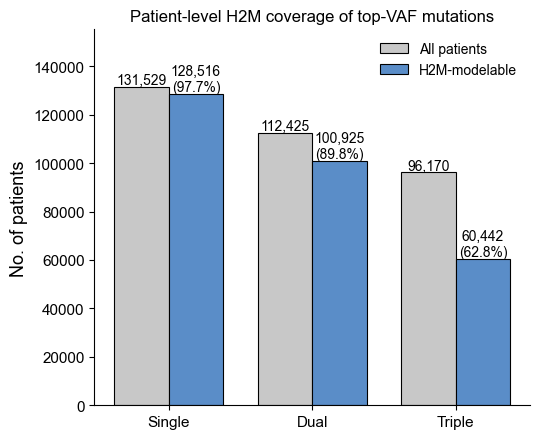

In [50]:
# --- Per-sample top-3 (keep sample info) ---
df_top3_per_sample = (
    df_mutation_aacr
    .sort_values('VAF', ascending=False)
    .groupby('Tumor_Sample_Barcode', sort=False)
    .head(3)
    .copy()
)
df_top3_per_sample['Hugo_Symbol'] = df_top3_per_sample['Hugo_Symbol'].replace(dict_of_aacr_symbol)
df_top3_per_sample['Chromosome'] = df_top3_per_sample['Chromosome'].astype(str)

# Merge H2M status
df_top3_per_sample = df_top3_per_sample.merge(
    h2m_lookup,
    on=['Hugo_Symbol', 'Chromosome', 'Start_Position', 'End_Position',
        'Reference_Allele', 'Tumor_Seq_Allele2'],
    how='left'
)
df_top3_per_sample['h2m_modelable'] = df_top3_per_sample['h2m_status'] == True

# Rank within sample by VAF (1 = highest)
df_top3_per_sample['vaf_rank'] = (
    df_top3_per_sample.groupby('Tumor_Sample_Barcode')['VAF']
    .rank(ascending=False, method='first').astype(int)
)

# --- Patient-level coverage: top-N all modelable ---
# Denominator: patients with at least N mutations (with VAF) — only these can have a "top-N"
counts_per_sample = df_top3_per_sample.groupby('Tumor_Sample_Barcode').size()
modelable_per_sample = df_top3_per_sample.groupby('Tumor_Sample_Barcode')['h2m_modelable'].sum()

results = {}
for n in [1, 2, 3]:
    eligible = counts_per_sample[counts_per_sample >= n].index
    n_total = len(eligible)
    n_covered = (modelable_per_sample.loc[eligible] >= n).sum()
    results[n] = (n_total, n_covered)
    print(f'Top-{n}: {n_covered:,}/{n_total:,} patients fully H2M-modelable ({n_covered/n_total*100:.1f}%)')

# --- Bar plot ---
labels = ['Single', 'Dual', 'Triple']
totals = [results[n][0] for n in [1, 2, 3]]
covered = [results[n][1] for n in [1, 2, 3]]
pcts = [c/t*100 for c, t in zip(covered, totals)]

blue_pair = '#5A8DC8'
gray = '#C8C8C8'

fig, ax = plt.subplots(figsize=(5.5, 4.5))
x = np.arange(len(labels))
w = 0.38
b1 = ax.bar(x - w/2, totals, w, color=gray, edgecolor='black', linewidth=0.8, label='All patients')
b2 = ax.bar(x + w/2, covered, w, color=blue_pair, edgecolor='black', linewidth=0.8, label='H2M-modelable')

for bar, val in zip(b1, totals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:,}',
            ha='center', va='bottom', fontsize=10)
for bar, val, pct in zip(b2, covered, pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)

ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=13)
ax.set_ylabel('No. of patients', fontsize=13)
ax.set_title('Patient-level H2M coverage of top-VAF mutations', fontsize=12)
ax.tick_params(axis='both', labelsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False, fontsize=10, loc='upper right')
ax.set_ylim(0, max(totals) * 1.18)
fig.tight_layout()
# plt.savefig('figures/h2m_patient_coverage.pdf', bbox_inches='tight')
plt.show()


In [51]:
# move forward to get PEGG modeling for the mouse orthologs of the top mutations.

list_id_mouse_variant = df_mut_top3_undup_h2m_fused[df_mut_top3_undup_h2m_fused['h2m_modelable'] == True]['ID_mouse'].to_list()

h2m_mouse_for_pegg = db_h2m[db_h2m['ID_mouse'].isin(list_id_mouse_variant)].reset_index(drop=True)
h2m_mouse_for_pegg

,gene_name_h,gene_id_h,tx_id_h,chr_h,exon_num_h,strand_h,match,start_h,end_h,ref_seq_h,...,ID_human,ID_mouse,Database,ID_db,pe_human,pe_mouse,be_human,be_mouse,expanded,flank_size
0,ABCB11,ENSG00000073734.8,ENST00000263817.6,chr2,27,-,True,169789016,169789017,TG,...,AACR-H0615015,AACR-H0615015-M01-V01,AACR,NaN,False,False,False,False,False,3
1,ABCB11,ENSG00000073734.8,ENST00000263817.6,chr2,27,-,True,169828535,169828535,C,...,AACR-H0009774,AACR-H0009774-M01-V01,AACR,NaN,False,False,False,False,False,9
2,ABCB11,ENSG00000073734.8,ENST00000263817.6,chr2,27,-,True,169826640,169826640,C,...,AACR-H0013347,AACR-H0013347-M01-V01,AACR,NaN,False,False,False,False,False,31
3,ABCB11,ENSG00000073734.8,ENST00000263817.6,chr2,27,-,True,169851992,169851992,T,...,AACR-H0032184,AACR-H0032184-M01-V01,AACR,NaN,False,False,False,False,False,1
4,ABCB11,ENSG00000073734.8,ENST00000263817.6,chr2,27,-,True,169781256,169781256,G,...,AACR-H0032477,AACR-H0032477-M01-V01,AACR,NaN,False,False,False,False,False,43
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149610,ZRSR2,ENSG00000169249.8,ENST00000307771.7,chrX,11,+,True,15826397,15826397,A,...,AACR-H0384994,AACR-H0384994-M01-V01,AACR,NaN,False,False,False,False,False,34
149611,ZRSR2,ENSG00000169249.8,ENST00000307771.7,chrX,11,+,True,15827443,15827443,T,...,AACR-H0385035,AACR-H0385035-M01-V01,AACR,NaN,False,False,False,False,False,3
149612,ZRSR2,ENSG00000169249.8,ENST00000307771.7,chrX,11,+,True,15818084,15818084,C,...,AACR-H0385066,AACR-H0385066-M01-V01,AACR,NaN,False,False,False,False,False,0
149613,ZRSR2,ENSG00000169249.8,ENST00000307771.7,chrX,11,+,True,15836648,15836648,T,...,AACR-H0000226,AACR-H0000226-M01-V01,AACR,NaN,True,True,False,False,True,2


In [60]:
# Truncate ID_mouse to the variant-level prefix (drop "-V01"/"-V02" suffix) and dedup
h2m_mouse_for_pegg['ID_mouse_dedup'] = h2m_mouse_for_pegg['ID_mouse'].str.rsplit('-', n=1).str[0]

n_total = len(h2m_mouse_for_pegg)
n_unique_variant = h2m_mouse_for_pegg['ID_mouse_dedup'].nunique()
n_unique_full = h2m_mouse_for_pegg['ID_mouse'].nunique()

print(f'Rows in h2m_mouse_for_pegg:               {n_total:,}')
print(f'Unique ID_mouse (full, with -V01 suffix): {n_unique_full:,}')
print(f'Unique ID_mouse (prefix only):            {n_unique_variant:,}')

# Keep one row per unique variant for PEGG
h2m_mouse_for_pegg_dedup = (
    h2m_mouse_for_pegg
    .drop_duplicates(subset='ID_mouse_dedup')
    .reset_index(drop=True)
)
print(f'Deduplicated dataframe size: {len(h2m_mouse_for_pegg_dedup):,}')

Rows in h2m_mouse_for_pegg:               149,615
Unique ID_mouse (full, with -V01 suffix): 149,615
Unique ID_mouse (prefix only):            137,633
Deduplicated dataframe size: 137,633


In [52]:
# process h2m data to use pegg
input = h2m_mouse_for_pegg.copy()

#editing columns to make them amenable to PEGG
input['Start_Position'] = [int(i) for i in input['start_m']] #had to change these coordinates to integers
input['End_Position'] = [int(i) for i in input['end_m']]
input['Variant_Type'] = input['type_m']
input['Reference_Allele'] = input['ref_seq_m']
input['Tumor_Seq_Allele2'] = input['alt_seq_m']
input['Chromosome'] = [i[3:] for i in input['chr_m']] #getting rid of "chr_"
input

,gene_name_h,gene_id_h,tx_id_h,chr_h,exon_num_h,strand_h,match,start_h,end_h,ref_seq_h,...,be_human,be_mouse,expanded,flank_size,Start_Position,End_Position,Variant_Type,Reference_Allele,Tumor_Seq_Allele2,Chromosome
0,ABCB11,ENSG00000073734.8,ENST00000263817.6,chr2,27,-,True,169789016,169789017,TG,...,False,False,False,3,69087680,69087681,DNP,TG,CA,2
1,ABCB11,ENSG00000073734.8,ENST00000263817.6,chr2,27,-,True,169828535,169828535,C,...,False,False,False,9,69117187,69117187,SNP,C,T,2
2,ABCB11,ENSG00000073734.8,ENST00000263817.6,chr2,27,-,True,169826640,169826640,C,...,False,False,False,31,69115639,69115639,SNP,C,T,2
3,ABCB11,ENSG00000073734.8,ENST00000263817.6,chr2,27,-,True,169851992,169851992,T,...,False,False,False,1,69136982,69136982,SNP,T,C,2
4,ABCB11,ENSG00000073734.8,ENST00000263817.6,chr2,27,-,True,169781256,169781256,G,...,False,False,False,43,69073848,69073848,SNP,G,A,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149610,ZRSR2,ENSG00000169249.8,ENST00000307771.7,chrX,11,+,True,15826397,15826397,A,...,False,False,False,34,162733180,162733180,SNP,T,G,X
149611,ZRSR2,ENSG00000169249.8,ENST00000307771.7,chrX,11,+,True,15827443,15827443,T,...,False,False,False,3,162736564,162736564,SNP,A,C,X
149612,ZRSR2,ENSG00000169249.8,ENST00000307771.7,chrX,11,+,True,15818084,15818084,C,...,False,False,False,0,162723094,162723094,SNP,G,A,X
149613,ZRSR2,ENSG00000169249.8,ENST00000307771.7,chrX,11,+,True,15836648,15836648,T,...,False,False,True,2,162739615,162739615,SNP,A,C,X


In [57]:
path_h_ref, path_m_ref = '/Users/kexindong/Documents/GitHub/Database/RefGenome/ncbi-2023-09-12/GCF_000001405.25_GRCh37.p13_genomic.fna.gz', '/Users/kexindong/Documents/GitHub/Database/RefGenome/mouse-2023-09-13/GCF_000001635.27_GRCm39_genomic.fna.gz'
# remember to replace the paths with yours
# records_m, index_list_m  = h2m.genome_loader(path_m_ref)
path_h_anno, path_m_anno = '/Users/kexindong/Documents/GitHub/Database/Genecode/gencode_v19_GRCh37.db', '/Users/kexindong/Documents/GitHub/Database/Genecode/gencode_vm33_GRCm39.db'
# remember to replace the paths with yours
chrom_dict, i = prime.genome_loader(path_m_ref)

In [59]:
input_format = 'cBioPortal'
pegRNAs = prime.run(input[:100], input_format, chrom_dict=chrom_dict, PAM = 'NGN', PBS_lengths=[7], RTT_lengths=[15])

Error in mutant # 58; Dropped from pegRNA generation
Variant Type = TNP| REF = GGC | ALT = ATG
CCTAGGGTTTAGCTCTGTGAATAAGGACTGTTCCCTCTTCTTCCTCAGCTGTACGTGTCCTCCGAGAGCCGCTTCAACACTCTGGCTGAGTTAGTTCACCATCACTCCACGGTGGCTGATGGCCTCATCACCACACTCCACTACCCAGCTCCCAAGCGCAACAAGCCCACTATCTACGGTGTGTCCCCCAACTACGACAAGTGGGAAATGGAGCGCACCGACATCACCATGAAGCACAAGTTG
TGAGCTATGTGGACTCTATCCAGCAGATGAGGAACAAGTTTGCCTTCCGTGAGGCTATCAACAAGCTGGAGAGCAACCTCCGAGAGCTGCAGATCTGCCCTGCCACAGCCTCCAGTGGGCGGCGCTGCCACCCAAGACTTCAGCAAGCTGCTCAGCTCTGTGAAGGAGATCAGCGACATTGTCCGGAGGTAGCAGCAACCAGTGTATGTCAGCAAGAGATGTTGCAGTTCACAGGGCTCTTGT


In [ ]:
df_mut_top3_undup_h2m_fused[df_mut_top3_undup_h2m_fused['h2m_modelable'] == True].head()

## proto-sample: sub cohort

In [61]:
# Center distribution of the top-3 mutations subset
print('--- Center distribution in top-3 mutations (per-row, can overcount patients with mixed-center samples) ---')
print(df_top3_per_sample['Center'].value_counts())
print()

print('--- Center distribution at the PATIENT level (one count per sample) ---')
center_per_sample = df_top3_per_sample.groupby('Tumor_Sample_Barcode')['Center'].first()
print(center_per_sample.value_counts())
print(f'\nTotal samples: {len(center_per_sample):,}')


--- Center distribution in top-3 mutations (per-row, can overcount patients with mixed-center samples) ---
Center
MSK     231025
PROV     43245
UCSF     34611
JHU      13438
UHN      11456
DUKE     10258
CRUK      6115
NKI       4801
VHIO      4249
MDA       4048
YALE      3208
CHOP      3087
WAKE      2956
VICC      2911
GRCC      2685
SCI       1864
UCHI      1497
COLU        13
Name: count, dtype: int64

--- Center distribution at the PATIENT level (one count per sample) ---
Center
MSK     77398
PROV    13221
UCSF    11159
JHU      6513
UHN      4440
DUKE     3115
NKI      2737
MDA      2190
CRUK     2035
VHIO     1660
WAKE     1396
GRCC     1302
YALE     1285
CHOP     1109
SCI       736
VICC      730
UCHI      500
COLU        3
Name: count, dtype: int64

Total samples: 131,529


In [62]:
# YALE patients & their cancer / age profile
yale_pts = df_pts[df_pts['CENTER'] == 'YALE']['PATIENT_ID']
yale_samples = df_sample[df_sample['PATIENT_ID'].isin(yale_pts)].copy()
print(f'YALE patients: {len(yale_pts):,}')
print(f'YALE samples:  {len(yale_samples):,}')
print()

# Age distribution
print('--- Age at sequencing (YALE) ---')
print(yale_samples['AGE_AT_SEQ_REPORT'].value_counts(dropna=False).head(10))
# coerce to numeric (some entries may be '<18' or '>89' strings)
age_numeric = pd.to_numeric(yale_samples['AGE_AT_SEQ_REPORT'], errors='coerce')
print(f'\nNumeric age — n={age_numeric.notna().sum():,}, median={age_numeric.median():.0f}, '
      f'mean={age_numeric.mean():.1f}, range=[{age_numeric.min():.0f}, {age_numeric.max():.0f}]')
print()

# Cancer type distribution
print('--- Top 15 cancer types (YALE) ---')
print(yale_samples['CANCER_TYPE'].value_counts().head(15))
print()
print(f'Total unique cancer types: {yale_samples["CANCER_TYPE"].nunique()}')


YALE patients: 1,357
YALE samples:  1,384

--- Age at sequencing (YALE) ---
AGE_AT_SEQ_REPORT
64    59
67    54
68    53
69    47
74    45
70    44
72    43
62    42
63    41
58    41
Name: count, dtype: int64

Numeric age — n=1,349, median=66, mean=64.8, range=[19, 88]

--- Top 15 cancer types (YALE) ---
CANCER_TYPE
Non-Small Cell Lung Cancer    375
Melanoma                      147
Colorectal Cancer             115
Prostate Cancer                84
Breast Cancer                  83
Esophagogastric Cancer         77
Head and Neck Cancer           75
Pancreatic Cancer              73
Hepatobiliary Cancer           54
Bladder Cancer                 50
Cancer of Unknown Primary      44
Soft Tissue Sarcoma            25
Glioma                         22
Thyroid Cancer                 18
Renal Cell Carcinoma           16
Name: count, dtype: int64

Total unique cancer types: 44


In [63]:
# Top mutations appearing in patients' top-3 VAF lists
# At gene level (most cancer-relevant view)
print('--- Top 20 genes (by # of times appearing in any patient\'s top-3) ---')
print(df_top3_per_sample['Hugo_Symbol'].value_counts().head(20))
print()

# At specific mutation level (gene + protein change)
df_top3_per_sample['mut_label'] = (
    df_top3_per_sample['Hugo_Symbol'] + ' '
    + df_top3_per_sample['HGVSp_Short'].fillna(
        df_top3_per_sample['Variant_Classification']
    )
)
print('--- Top 20 specific mutations (gene + HGVSp) ---')
print(df_top3_per_sample['mut_label'].value_counts().head(20))
print()

# Same but only top-1 (the most clonal mutation per patient)
print('--- Top 20 mutations seen as the #1 most-clonal (top-1) mutation ---')
print(df_top3_per_sample[df_top3_per_sample['vaf_rank']==1]['mut_label'].value_counts().head(20))


--- Top 20 genes (by # of times appearing in any patient's top-3) ---
Hugo_Symbol
TP53      50394
KRAS      13679
PIK3CA     8181
APC        7574
HLA-A      6194
HLA-B      5630
EGFR       5464
PTEN       5428
TERT       4792
BRAF       4323
ARID1A     3720
KMT2D      3658
RB1        3499
TET2       3424
IDH1       3353
ATM        3134
DNMT3A     2803
NF1        2664
SMAD4      2625
NOTCH1     2507
Name: count, dtype: int64

--- Top 20 specific mutations (gene + HGVSp) ---
mut_label
TERT 5'Flank           4425
KRAS p.G12D            3804
KRAS p.G12V            3229
BRAF p.V600E           2753
TP53 p.R248Q           2643
TP53 p.R213*           2452
TP53 p.R175H           2073
PIK3CA p.H1047R        1968
KRAS p.G12C            1966
TP53 p.R196*           1764
IDH1 p.R132H           1726
TP53 p.R342*           1701
PIK3CA p.E545K         1643
JAK2 p.V617F           1498
TP53 p.R273H           1277
TP53 p.R273C           1246
TP53 p.R248W           1129
EGFR p.L858R           1099
EGFR p.E

In [ ]:
# --- Subset input to mutations from YALE patients only ---

# 1. YALE patient IDs
yale_pts = df_pts[df_pts['CENTER'] == 'YALE']['PATIENT_ID']

# 2. YALE samples
yale_samples = df_sample[df_sample['PATIENT_ID'].isin(yale_pts)]['SAMPLE_ID']

# 3. Top-3 mutations from YALE samples that are H2M-modelable
yale_top3_modelable = df_top3_per_sample[
    (df_top3_per_sample['Tumor_Sample_Barcode'].isin(yale_samples)) &
    (df_top3_per_sample['h2m_modelable'] == True)
]

# 4. Get the corresponding ID_mouse list (truncated to variant level)
yale_id_mouse_set = set(yale_top3_modelable['ID_mouse'].dropna().unique())

# 5. Subset PEGG input
input_yale = input[input['ID_mouse'].isin(yale_id_mouse_set)].reset_index(drop=True)
# Map MAF variant types to PEGG's expected vocabulary
# PEGG only knows: SNP, ONP, DNP, INDEL, INS, DEL
# MAF uses: SNP, DNP, TNP, ONP -> in PEGG, DNP/TNP/ONP all = "ONP" (multi-bp substitution)
input_yale['Variant_Type'] = input_yale['Variant_Type'].replace({
    'TNP': 'ONP',
    # DNP is already in PEGG's vocab, no change needed
})

# Verify
print(input_yale['Variant_Type'].value_counts())

# Dedup at variant level (drop -V01 suffix)
input_yale['ID_mouse_dedup'] = input_yale['ID_mouse'].str.rsplit('-', n=1).str[0]
input_yale = input_yale.drop_duplicates(subset='ID_mouse_dedup').reset_index(drop=True)

print(f'YALE patients:                          {len(yale_pts):,}')
print(f'YALE samples:                           {len(yale_samples):,}')
print(f'YALE top-3 H2M-modelable mutation rows: {len(yale_top3_modelable):,}')
print(f'Unique YALE mouse variants for PEGG:    {len(input_yale):,}')
print(f'Estimated PEGG runtime (@5.18 muts/s):  {len(input_yale)/5.18/60:.1f} min')

# --- Run PEGG on YALE subset ---
input_format = 'cBioPortal'
pegRNAs = prime.run(
    input_yale,
    input_format,
    chrom_dict=chrom_dict,
    PAM='NGN',
    PBS_lengths=[7],
    RTT_lengths=[15]
)

print(f'\npegRNAs designed: {len(pegRNAs):,}')


In [66]:
print(f'pegRNAs designed: {len(pegRNAs):,}')

# Identify unique mutations by coordinate
unique_mut_cols = ['Chromosome', 'Start_Position', 'End_Position', 'Reference_Allele', 'Tumor_Seq_Allele2']
if all(c in pegRNAs.columns for c in unique_mut_cols):
    n_unique_muts = pegRNAs[unique_mut_cols].drop_duplicates().shape[0]
    print(f'Unique mutations with at least one pegRNA: {n_unique_muts:,}')

# How many input mutations got dropped
n_input = len(input_yale)
n_with_peg = pegRNAs[unique_mut_cols].drop_duplicates().shape[0] if all(c in pegRNAs.columns for c in unique_mut_cols) else None
print(f'Input mutations:    {n_input:,}')
print(f'With ≥1 pegRNA:     {n_with_peg:,}' if n_with_peg else 'check columns')
print(f'Dropped by PEGG:    {n_input - (n_with_peg or 0):,}')
# Save
pegRNAs.to_csv('data/pegRNAs_yale.csv', index=False)

pegRNAs designed: 11,774
Unique mutations with at least one pegRNA: 1,608
Input mutations:    1,612
With ≥1 pegRNA:     1,608
Dropped by PEGG:    4


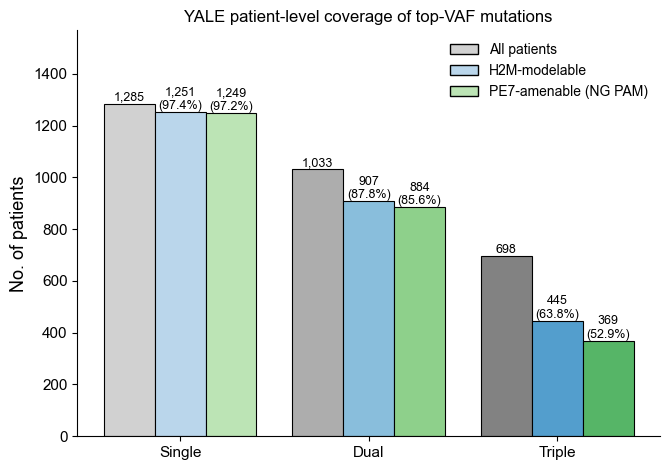

In [73]:
# --- 3-bar plot with gradient by N (1=lightest, 3=darkest) ---
labels = ['Single', 'Dual', 'Triple']
totals  = [results_yale[n][0] for n in [1, 2, 3]]
h2m_cov = [results_yale[n][1] for n in [1, 2, 3]]
pe7_cov = [results_yale[n][2] for n in [1, 2, 3]]
h2m_pct = [c/t*100 for c, t in zip(h2m_cov, totals)]
pe7_pct = [c/t*100 for c, t in zip(pe7_cov, totals)]

# Gradient palettes — index 0 = lightest (Single), index 2 = darkest (Triple)
grays_3  = sns.color_palette('Greys',  6)[1:4]   # skip very light/dark ends
blues_3  = sns.color_palette('Blues',  6)[1:4]
greens_3 = sns.color_palette('Greens', 6)[1:4]

fig, ax = plt.subplots(figsize=(6.8, 4.8))
x = np.arange(len(labels))
w = 0.27

bars_total = []
bars_h2m   = []
bars_pe7   = []
for i in range(3):
    bars_total.append(ax.bar(x[i] - w, totals[i],  w,
                             color=grays_3[i],  edgecolor='black', linewidth=0.8))
    bars_h2m.append(  ax.bar(x[i],     h2m_cov[i], w,
                             color=blues_3[i],  edgecolor='black', linewidth=0.8))
    bars_pe7.append(  ax.bar(x[i] + w, pe7_cov[i], w,
                             color=greens_3[i], edgecolor='black', linewidth=0.8))

# annotations
for i in range(3):
    ax.text(x[i] - w, totals[i],  f'{totals[i]:,}',
            ha='center', va='bottom', fontsize=9)
    ax.text(x[i],     h2m_cov[i], f'{h2m_cov[i]:,}\n({h2m_pct[i]:.1f}%)',
            ha='center', va='bottom', fontsize=9)
    ax.text(x[i] + w, pe7_cov[i], f'{pe7_cov[i]:,}\n({pe7_pct[i]:.1f}%)',
            ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=13)
ax.set_ylabel('No. of patients', fontsize=13)
ax.set_title('YALE patient-level coverage of top-VAF mutations', fontsize=12)
ax.tick_params(axis='both', labelsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylim(0, max(totals) * 1.22)

# Custom legend (use the darkest swatch of each color family as the representative)
from matplotlib.patches import Patch
legend_elems = [
    Patch(facecolor=grays_3[0],  edgecolor='black', label='All patients'),
    Patch(facecolor=blues_3[0],  edgecolor='black', label='H2M-modelable'),
    Patch(facecolor=greens_3[0], edgecolor='black', label='PE7-amenable (NG PAM)'),
]

ax.legend(handles=legend_elems, frameon=False, fontsize=10, loc='upper right')

fig.tight_layout()
plt.savefig('figures/yale_patient_coverage.pdf', bbox_inches='tight')
plt.show()


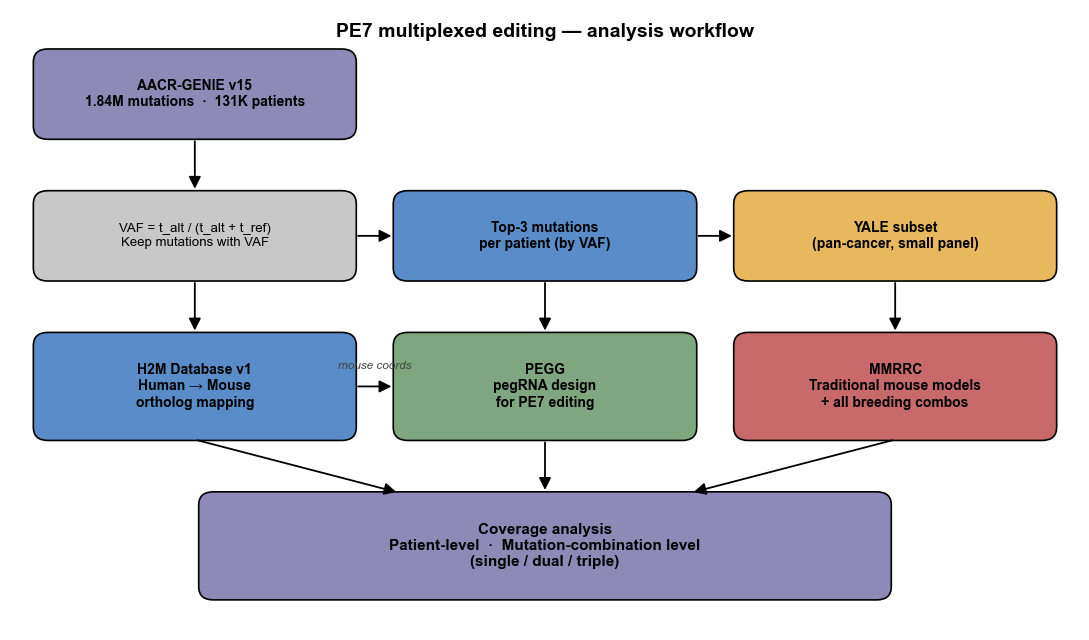

In [72]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# Colors
gray_bg     = '#C8C8C8'
purple_muted = '#8E8AB8'
blue_pair   = '#5A8DC8'
green_muted = '#7FA77F'
gold_pair   = '#E8B85F'
red_ctrl    = '#C86A6A'

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.set_xlim(0, 11)
ax.set_ylim(0, 7)
ax.axis('off')

def box(x, y, w, h, text, color, fontsize=10, fontweight='normal'):
    p = FancyBboxPatch((x, y), w, h,
                       boxstyle="round,pad=0.06,rounding_size=0.15",
                       facecolor=color, edgecolor='black', linewidth=1.2)
    ax.add_patch(p)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center',
            fontsize=fontsize, fontweight=fontweight, wrap=True)

def arrow(x1, y1, x2, y2, label=None, label_offset=(0, 0.2)):
    a = FancyArrowPatch((x1, y1), (x2, y2),
                        arrowstyle='-|>', mutation_scale=18,
                        color='black', linewidth=1.3)
    ax.add_patch(a)
    if label:
        ax.text((x1+x2)/2 + label_offset[0], (y1+y2)/2 + label_offset[1],
                label, ha='center', fontsize=8.5, style='italic', color='#444')

# === Row 1: Input ===
box(0.3, 5.6, 3.2, 0.9,
    'AACR-GENIE v15\n1.84M mutations  ·  131K patients',
    purple_muted, fontsize=10, fontweight='bold')

# === Row 2: VAF filter & top-3 selection ===
box(0.3, 4.0, 3.2, 0.9,
    'VAF = t_alt / (t_alt + t_ref)\nKeep mutations with VAF',
    gray_bg, fontsize=9.5)

box(4.0, 4.0, 3.0, 0.9,
    'Top-3 mutations\nper patient (by VAF)',
    blue_pair, fontsize=10, fontweight='bold')

# Right side: Cohort selection
box(7.5, 4.0, 3.2, 0.9,
    'YALE subset\n(pan-cancer, small panel)',
    gold_pair, fontsize=10, fontweight='bold')

# === Row 3: Two parallel modeling tracks ===
# H2M track
box(0.3, 2.2, 3.2, 1.1,
    'H2M Database v1\nHuman → Mouse\northolog mapping',
    blue_pair, fontsize=10, fontweight='bold')

# PEGG track
box(4.0, 2.2, 3.0, 1.1,
    'PEGG\npegRNA design\nfor PE7 editing',
    green_muted, fontsize=10, fontweight='bold')

# Traditional mouse model
box(7.5, 2.2, 3.2, 1.1,
    'MMRRC\nTraditional mouse models\n+ all breeding combos',
    red_ctrl, fontsize=10, fontweight='bold')

# === Row 4: Coverage analysis ===
box(2.0, 0.4, 7.0, 1.1,
    'Coverage analysis\nPatient-level  ·  Mutation-combination level\n(single / dual / triple)',
    purple_muted, fontsize=11, fontweight='bold')

# === Arrows ===
# Row1 -> VAF
arrow(1.9, 5.55, 1.9, 4.95)
# VAF -> top-3
arrow(3.55, 4.45, 3.95, 4.45)
# top-3 -> YALE
arrow(7.05, 4.45, 7.45, 4.45)

# Top-3/YALE -> H2M, PEGG, MMRRC
arrow(1.9, 3.95, 1.9, 3.35)
arrow(5.5, 3.95, 5.5, 3.35)
arrow(9.1, 3.95, 9.1, 3.35)

# H2M -> PEGG (PEGG needs H2M-modelable mouse coords)
arrow(3.55, 2.75, 3.95, 2.75, label='mouse coords')

# All three -> Coverage
arrow(1.9, 2.15, 4.0, 1.55)
arrow(5.5, 2.15, 5.5, 1.55)
arrow(9.1, 2.15, 7.0, 1.55)

# === Title ===
ax.text(5.5, 6.75, 'PE7 multiplexed editing — analysis workflow',
        ha='center', va='center', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/workflow.pdf', bbox_inches='tight')
plt.show()
